In [20]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Load and merge data

In [ ]:
df1=pl.read_parquet(
    'items.parquet',
    columns=['item_id','category_l1','category_l2','category_l3','category'])
df2=pl.read_parquet(
    'transactions-202411-to-202412.parquet',
    columns=['updated_date', 'item_id', 'quantity']    
)
df=df1.join(df2, on='item_id', how='left')
df=df.drop_nulls()
print(len(df))
print(df.head())

6053447
shape: (5, 7)
┌────────────────┬─────────────┬───────────────┬─────────────┬──────────┬───────────────┬──────────┐
│ item_id        ┆ category_l1 ┆ category_l2   ┆ category_l3 ┆ category ┆ updated_date  ┆ quantity │
│ ---            ┆ ---         ┆ ---           ┆ ---         ┆ ---      ┆ ---           ┆ ---      │
│ str            ┆ str         ┆ str           ┆ str         ┆ str      ┆ datetime[μs]  ┆ i32      │
╞════════════════╪═════════════╪═══════════════╪═════════════╪══════════╪═══════════════╪══════════╡
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty   ┆ 2024-12-30    ┆ 1        │
│                ┆             ┆ kiện          ┆             ┆ Pigeon   ┆ 10:22:00.050  ┆          │
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty   ┆ 2024-12-28    ┆ 1        │
│                ┆             ┆ kiện          ┆             ┆ Pigeon   ┆ 13:39:11.750  ┆          │
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty

# 2. Gom quantity theo week

In [54]:
import polars as pl

df = df.with_columns([
    pl.col("updated_date").cast(pl.Datetime).dt.month().alias("month"),
    pl.col("updated_date").cast(pl.Datetime).dt.day().alias("day")
]).with_columns(
    pl.when((pl.col("month") == 11) & (pl.col("day") <= 7)).then(1)
      .when((pl.col("month") == 11) & (pl.col("day") <= 14)).then(2)
      .when((pl.col("month") == 11) & (pl.col("day") <= 21)).then(3)
      .when((pl.col("month") == 11) & (pl.col("day") >= 22)).then(4)
      .when((pl.col("month") == 12) & (pl.col("day") <= 7)).then(5)
      .when((pl.col("month") == 12) & (pl.col("day") <= 14)).then(6)
      .when((pl.col("month") == 12) & (pl.col("day") <= 21)).then(7)
      .when((pl.col("month") == 12) & (pl.col("day") >= 22)).then(8)
      .otherwise(None).alias("week_id")
)

df = df.drop_nulls(subset=["week_id"]).drop(["month", "day"])

group_cols = ['item_id', 'category_l1', 'category_l2', 'category_l3', 'category', 'week_id']

df_grouped = df.group_by(group_cols).agg(
    pl.col("quantity").sum().alias("quantity")
)

df_final = df_grouped.with_columns(
    pl.when(pl.col("week_id") == 4).then(pl.col("quantity") / 9)
      .when(pl.col("week_id") == 8).then(pl.col("quantity") / 10)
      .otherwise(pl.col("quantity") / 7).alias("normalized_quantity")
)

df_final = df_final.drop("quantity")

df_final = df_final.sort(["item_id", "week_id"])

print(df_final.head())
df_final.write_parquet('ket_qua_kinh_doanh.parquet')

shape: (5, 7)
┌──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬─────────┬──────────────┐
│ item_id      ┆ category_l1  ┆ category_l2 ┆ category_l3  ┆ category     ┆ week_id ┆ normalized_q │
│ ---          ┆ ---          ┆ ---         ┆ ---          ┆ ---          ┆ ---     ┆ uantity      │
│ str          ┆ str          ┆ str         ┆ str          ┆ str          ┆ i32     ┆ ---          │
│              ┆              ┆             ┆              ┆              ┆         ┆ f64          │
╞══════════════╪══════════════╪═════════════╪══════════════╪══════════════╪═════════╪══════════════╡
│ 000028000013 ┆ Đồ chơi &    ┆ 1Y+         ┆ Đồ chơi nước ┆ Đồ chơi nhà  ┆ 1       ┆ 74.142857    │
│ 8            ┆ Sách         ┆             ┆              ┆ tắm          ┆         ┆              │
│ 000028000013 ┆ Đồ chơi &    ┆ 1Y+         ┆ Đồ chơi nước ┆ Đồ chơi nhà  ┆ 2       ┆ 74.571429    │
│ 8            ┆ Sách         ┆             ┆              ┆ tắm          ┆  

# 3. Visualize

## 3.1 Group by theo toàn bộ

shape: (8, 2)
┌─────────┬────────────────┐
│ week_id ┆ total_quantity │
│ ---     ┆ ---            │
│ i32     ┆ f64            │
╞═════════╪════════════════╡
│ 1       ┆ 151337.571429  │
│ 2       ┆ 170517.142857  │
│ 3       ┆ 141132.571429  │
│ 4       ┆ 168366.111111  │
│ 5       ┆ 151011.0       │
│ 6       ┆ 154340.428571  │
│ 7       ┆ 147385.857143  │
│ 8       ┆ 133586.4       │
└─────────┴────────────────┘


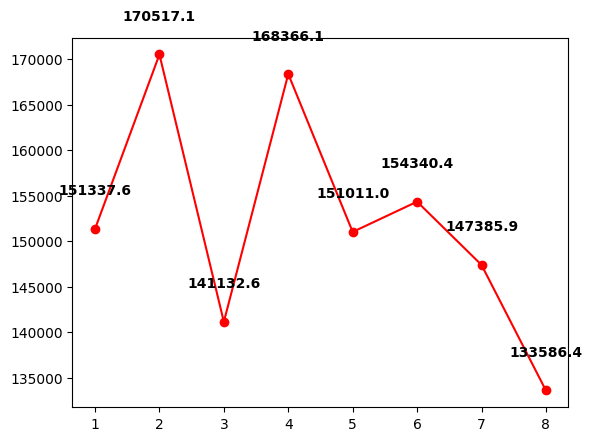

In [53]:
df_combo = df_final.group_by('week_id').agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_combo=df_combo.sort('week_id')
print(df_combo)

plt.plot(df_combo['week_id'], df_combo['total_quantity'], 'r', marker='o')
for x, y in zip(df_combo['week_id'], df_combo['total_quantity']):
        plt.text(x, y + (max(df_combo['total_quantity']) * 0.02), f"{y:.1f}", 
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

## 3.2 Group by theo cat 1

In [28]:
df_cat1 = df_final.group_by(['category_l1', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat1=df_cat1.sort('week_id')
print(df_cat1.head())
print(len(df_cat1))

shape: (5, 3)
┌────────────────────┬─────────┬────────────────┐
│ category_l1        ┆ week_id ┆ total_quantity │
│ ---                ┆ ---     ┆ ---            │
│ str                ┆ i32     ┆ f64            │
╞════════════════════╪═════════╪════════════════╡
│ Sữa                ┆ 1       ┆ 16786.857143   │
│ Textile            ┆ 1       ┆ 2125.428571    │
│ Đồ chơi & Sách     ┆ 1       ┆ 1782.714286    │
│ Hóa mỹ phẩm cho bé ┆ 1       ┆ 9093.571429    │
│ TPCN               ┆ 1       ┆ 3738.857143    │
└────────────────────┴─────────┴────────────────┘
112


## 3.3 Group by theo cat 2

In [30]:
df_cat2 = df_final.group_by(['category_l2', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat2=df_cat2.sort('week_id')
print(df_cat2.head())
print(len(df_cat2))

shape: (5, 3)
┌─────────────────────────────┬─────────┬────────────────┐
│ category_l2                 ┆ week_id ┆ total_quantity │
│ ---                         ┆ ---     ┆ ---            │
│ str                         ┆ i32     ┆ f64            │
╞═════════════════════════════╪═════════╪════════════════╡
│ Chăm sóc sức khỏe bé        ┆ 1       ┆ 1421.0         │
│ Khăn em bé                  ┆ 1       ┆ 1294.857143    │
│ Nước rửa bình sữa           ┆ 1       ┆ 2051.714286    │
│ Meiji                       ┆ 1       ┆ 1628.142857    │
│ TP từ sữa (bảo quản thường) ┆ 1       ┆ 765.428571     │
└─────────────────────────────┴─────────┴────────────────┘
912


## 3.4 Group by theo cat 3

In [32]:
df_cat3 = df_final.group_by(['category_l3', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat3=df_cat3.sort('week_id')
print(df_cat3.head())
print(len(df_cat3))

shape: (5, 3)
┌────────────────────────────┬─────────┬────────────────┐
│ category_l3                ┆ week_id ┆ total_quantity │
│ ---                        ┆ ---     ┆ ---            │
│ str                        ┆ i32     ┆ f64            │
╞════════════════════════════╪═════════╪════════════════╡
│ Khăn gạc, khăn sữa         ┆ 1       ┆ 704.285714     │
│ Gối nằm cao su             ┆ 1       ┆ 82.142857      │
│ Đồ dùng ra ngoài ngừng bán ┆ 1       ┆ 0.857143       │
│ Phụ  kiện tồn              ┆ 1       ┆ 18.428571      │
│ Abbott Grow                ┆ 1       ┆ 421.428571     │
└────────────────────────────┴─────────┴────────────────┘
3145


## 3.5 Group by theo category

In [34]:
df_cat = df_final.group_by(['category', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat=df_cat.sort('week_id')
print(df_cat.head())
print(len(df_cat))

shape: (5, 3)
┌──────────────────────────┬─────────┬────────────────┐
│ category                 ┆ week_id ┆ total_quantity │
│ ---                      ┆ ---     ┆ ---            │
│ str                      ┆ i32     ┆ f64            │
╞══════════════════════════╪═════════╪════════════════╡
│ Nước rửa bình sữa Arau   ┆ 1       ┆ 213.714286     │
│ Nước súc miệng Listerine ┆ 1       ┆ 17.428571      │
│ Bàn chải điện            ┆ 1       ┆ 3.0            │
│ Corniche                 ┆ 1       ┆ 59.714286      │
│ Biogaia                  ┆ 1       ┆ 231.285714     │
└──────────────────────────┴─────────┴────────────────┘
9837


## 3.6 Group by theo item_id

In [35]:
df_item = df_final.group_by(['item_id', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_item=df_item.sort('week_id')
print(df_item.head())
print(len(df_item))

shape: (5, 3)
┌───────────────┬─────────┬────────────────┐
│ item_id       ┆ week_id ┆ total_quantity │
│ ---           ┆ ---     ┆ ---            │
│ str           ┆ i32     ┆ f64            │
╞═══════════════╪═════════╪════════════════╡
│ 2155000000046 ┆ 1       ┆ 0.142857       │
│ 3953000000090 ┆ 1       ┆ 2.142857       │
│ 3944000000386 ┆ 1       ┆ 1.142857       │
│ 3492000000032 ┆ 1       ┆ 5.571429       │
│ 4562000000026 ┆ 1       ┆ 0.571429       │
└───────────────┴─────────┴────────────────┘
79880


## 3.7 Plot theo item_id hoặc category

Cách truyền tham số vào hàm:
- Type = 0: plot theo category
- Type = 1: plot theo cat 1
- Type = 2: plot theo cat 2
- Type = 3: plot theo cat 3
- Type = 4: plot theo item_id

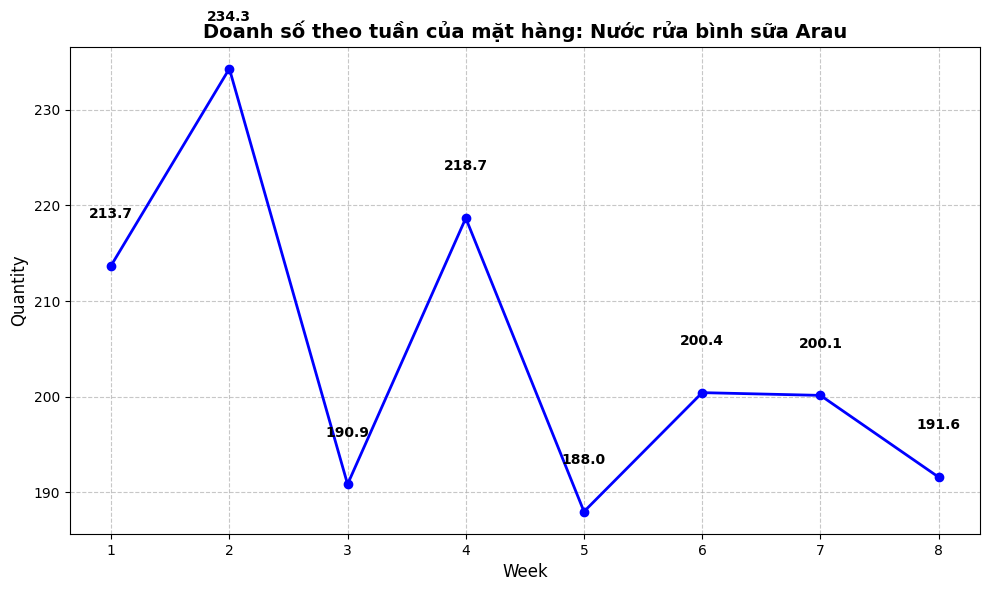

In [49]:
def visualize(name, type):
    if type==0:
        df_filtered = df_cat.filter(pl.col("category") == name).sort("week_id")
    elif type==1:
        df_filtered = df_cat1.filter(pl.col("category_l1") == name).sort("week_id")
    elif type==2:
        df_filtered = df_cat2.filter(pl.col("category_l2") == name).sort("week_id")
    elif type==3:
        df_filtered = df_cat3.filter(pl.col("category_l3") == name).sort("week_id")
    elif type==4:
        df_filtered = df_item.filter(pl.col("item_id") == name).sort("week_id")

    plt.figure(figsize=(10, 6))

    plt.plot(df_filtered['week_id'], df_filtered['total_quantity'], marker='o', color='blue', linewidth=2)

    for x, y in zip(df_filtered['week_id'], df_filtered['total_quantity']):
        plt.text(x, y + (max(df_filtered['total_quantity']) * 0.02), f"{y:.1f}", 
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

    plt.title(f"Doanh số theo tuần của mặt hàng: {name}", fontsize=14, fontweight='bold')
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Quantity", fontsize=12)

    plt.xticks([1,2,3,4,5,6,7,8]) 

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.show()

visualize('Nước rửa bình sữa Arau', 0)